<h1>ENSO RMSE - SPREAD - SATURATION</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys
import xarray as xr

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)
    
from src.datareader import datareader as dr
from src.util import util, stats

import warnings
warnings.filterwarnings('ignore')

<h5>Get data readers</h5>

In [3]:
# seas5 sst data are here:
seas5_dir = '/groups/ORC-CLIMATE/aoes_repo/models/seas5/monthly/mean/sst/'

In [4]:
# Collect all sst seas5 files in known directory.
seas5_file_list = os.listdir(seas5_dir)

# Prepend file paths.
seas5_file_list = [os.path.join(seas5_dir, this_file) for this_file in seas5_file_list]

In [5]:
# netcdf4 package is needed here.
seas5_ds = xr.open_mfdataset(seas5_file_list, engine='netcdf4')

In [6]:
# Rename dimensions/coordinates to match our init+lead paradigm.
seas5_ds = seas5_ds.rename_dims({'forecast_reference_time': 'init',
                                 'forecastMonth': 'lead',
                                  'number': 'member'})

seas5_ds = seas5_ds.rename({'forecast_reference_time': 'init',
                            'forecastMonth': 'lead',
                            'number': 'member'})

# By default the lead unit is defined as '1', but we know it's really 'months'.
seas5_ds['lead'].attrs['units'] = 'months'

# Wrap it up into a DataReader object.
seas5_data_reader = dr.getDataReader(datasource='SUPPLIED', dataset=seas5_ds)

In [7]:
ufs_experiments = ['baseline', 'beta.0.1', 'cpc_ics']

ufs_data_readers = [dr.getDataReader(datasource='UFS',
                                     # filename=f'experiments/phase_1/{m}/atm_monthly.zarr',
                                     experiment = this_experiment,
                                     model='atm')
                    for this_experiment in ufs_experiments]

No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/baseline/atm_monthly.zarr
No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/beta.0.1/atm_monthly.zarr
No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/cpc_ics/atm_monthly.zarr


In [8]:
era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [9]:
ufs_vars = ['tmpsfc', 'tsfc']
era5_var = 'sea_surface_temperature'
seas5_var = 'sst'

<h5>Define time period</h5>

In [10]:
time_range = ("1994-11-01", "2021-10-31T23")
initmonths = (11,)

<h5>Define nino 3.4 region</h5>

In [11]:
region = {
    'latmin': -5.0,
    'latmax': 5.0,
    'lonmin': 190.0,
    'lonmax':240.0
}

<h5>Get climatology statistics for nino 3.4</h5>

In [12]:
# Enter a list of members, like [1, 2, 6, 8, ens_avg]
# Note that 'ens_avg' is a special keyword in the ensuing code.
# If you include 'ens_avg' in the list of members,
# then the Ensemble Average will be listed under member = -1
members = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 'ens_avg']

# We know that seas5 hindcast has members 0-24.
seas5_members = list(range(25)) + ['ens_avg']

<h5>Statistical accumulation will take a few minutes... please be patient.</h5>

In [13]:
%%capture captured_output
# Begin analyzing seas5 first...

seas5_ds = util.retrieve_ufs_dataset(seas5_data_reader,
                                     'sst',
                                      time_range,
                                      seas5_members,
                                      region,
                                      initmonths=initmonths)

seas5_stats =  stats.calc_climatology_anomaly(seas5_ds, area_mean=True)

In [14]:
%%capture captured_output
# ...then the rest of the UFS datasets.
ufs_dss = []
ufs_var_list = []
ufs_stats = []

for this_dr in ufs_data_readers:
    
    for this_var in ufs_vars:                                                                                   
        if this_var in list(this_dr.dataset().keys()):                                                               
            ufs_var = this_var

    ufs_var_list.append(ufs_var)  # Keep track of which ufs variable name is used here.
    
    # Get datasets
    this_ds = util.retrieve_ufs_dataset(this_dr, ufs_var, time_range, members, region, initmonths=initmonths)
    ufs_dss.append(this_ds)
    
    # Calculate climatology statistics
    ufs_stats.append(stats.calc_climatology_anomaly(this_ds, area_mean=True))

In [15]:
era5_ds = era5_data_reader.retrieve(var=era5_var,
                                    lat=(region['latmin'], region['latmax']),
                                    lon=(region['lonmin'], region['lonmax']),
                                    time=time_range)

In [16]:
# ERA5 climatology statistics
era5_stats = stats.calc_climatology_anomaly(era5_ds, area_mean=True)

<h3>Accumulating RMSE and SPREAD statistics for each UFS model.  This may take some time!</h3>

In [17]:
# ufs_ds: xr.Dataset
# ufs_var: str
# ufs_stats: dict
# verif_ds: xr.Dataset
# erif_var: str
# verif_stats: dict
                    
rmses = [stats.calc_rmse_spread(ufs_dss[i], ufs_var_list[i], ufs_stats[i], era5_ds, era5_var, era5_stats)
         for i in range(len(ufs_dss))]

seas5_rmse = stats.calc_rmse_spread(seas5_ds, 'sst', seas5_stats, era5_ds, era5_var, era5_stats)

Number of ensemble members: 11
Number of years: 27
Accumulating Statistics...
Finished.
Number of ensemble members: 11
Number of years: 27
Accumulating Statistics...
Finished.
Number of ensemble members: 11
Number of years: 27
Accumulating Statistics...
Finished.
Number of ensemble members: 25
Number of years: 27
Accumulating Statistics...
Finished.


<h2>Plot statistics</h2>

In [18]:
ufs_experiments.insert(2, 'seas5')
rmses.insert(2, seas5_rmse)

<module 'matplotlib.pyplot' from '/home/thamzey/miniforge2/envs/copernicus/lib/python3.11/site-packages/matplotlib/pyplot.py'>

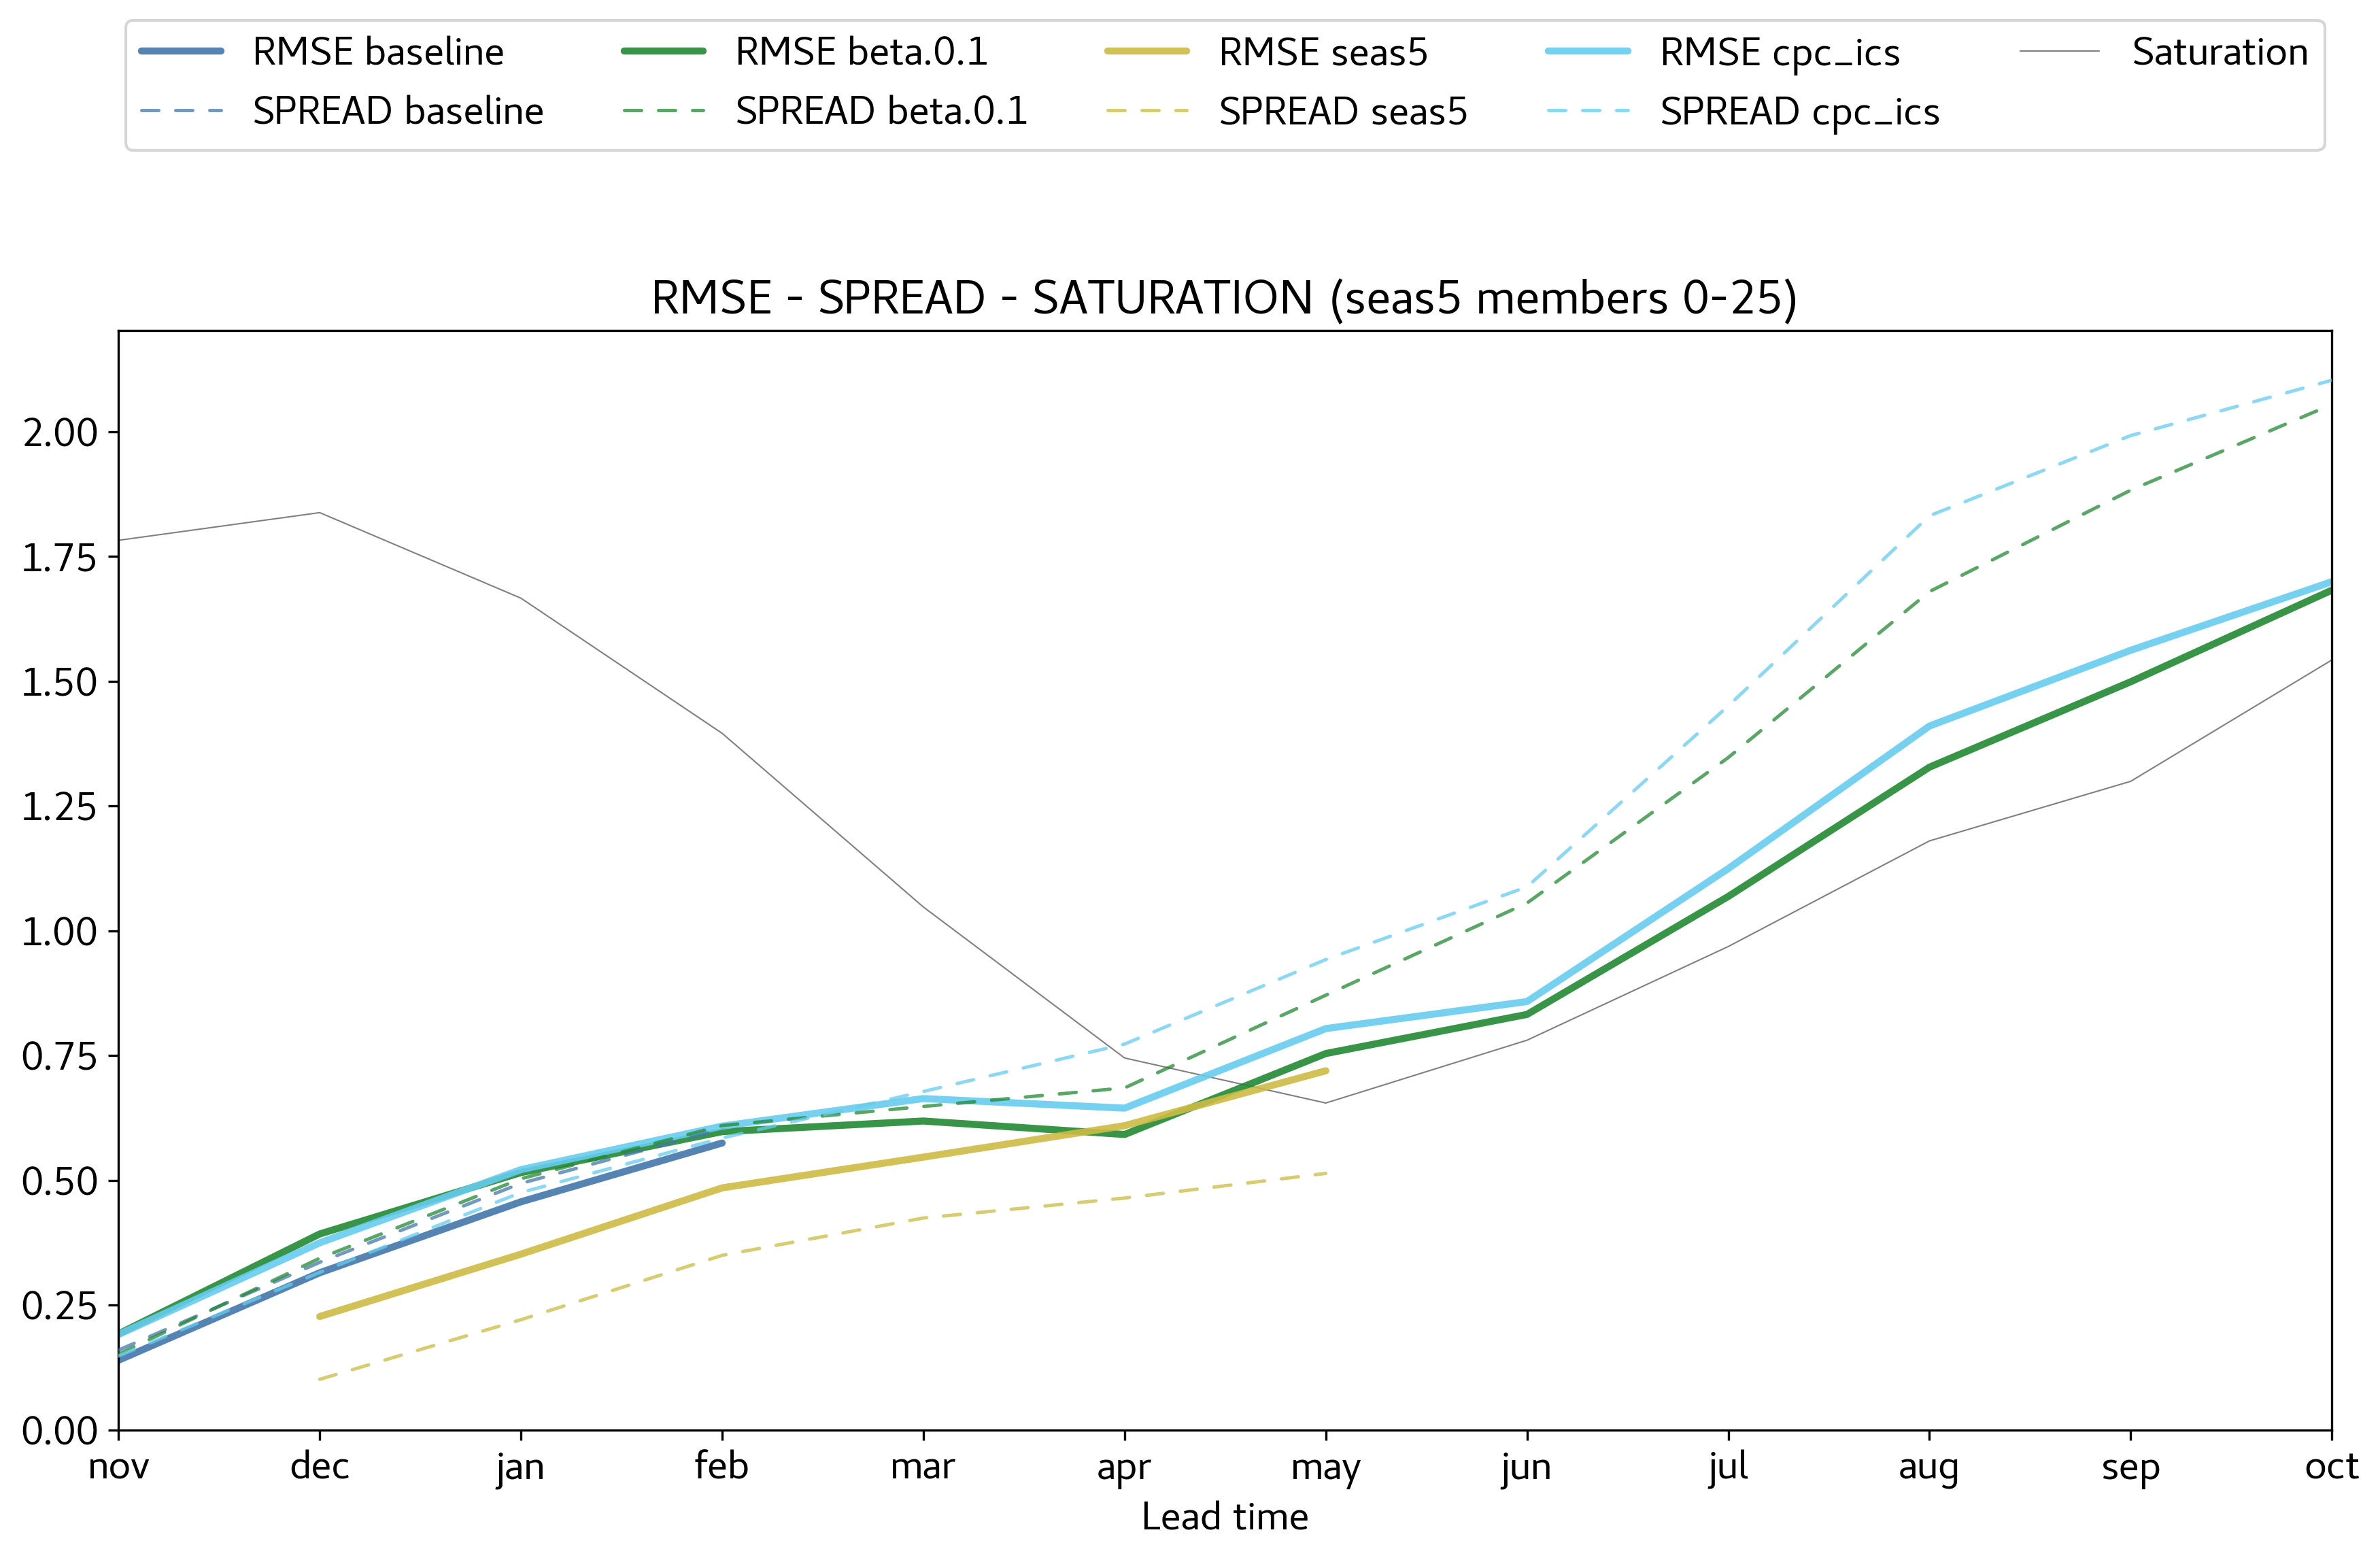

In [19]:
stats.plot_rmse_spread(rmses,
                       ufs_experiments,
                       rmse_only=False,
                       spread_only=False,
                       verif_stats=era5_stats,
                       title='RMSE - SPREAD - SATURATION (seas5 members 0-25)',
                       dpi=300)